In [1]:
from matplotlib import pyplot as plt
import zarr
import numpy as np
from dask import array as da

reall_small_zarr = "/home/willfaw/data16"
aia_data = zarr.group(zarr.DirectoryStore(reall_small_zarr))
aia_data[2010]['131A'].info

Name,/2010/131A
Type,zarr.core.Array
Data type,float16
Shape,"(471, 512, 512)"
Chunk shape,"(59, 128, 128)"
Order,C
Read-only,False
Compressor,"Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0)"
Store type,zarr.storage.DirectoryStore
No. bytes,246939648 (235.5M)
No. bytes stored,217084107 (207.0M)


In [2]:
years = ['2010', '2011', '2012', '2013', '2014']
wavelengths = ['131A', '1600A', '1700A', '171A', '193A', '211A', '304A', '335A', '94A']

#years = ['2010']
wavelengths = ['131A']

In [3]:
# plot pixel values of one image
aia_data[2010]['131A'].shape

(471, 512, 512)

In [4]:
image1 = aia_data[2010]['131A'][0]
print(type(image1))
print(image1.shape)

<class 'numpy.ndarray'>
(512, 512)


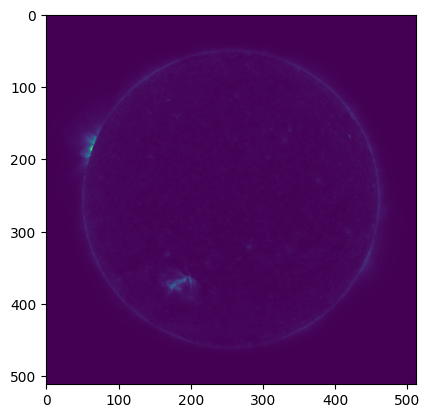

In [5]:
plt.imshow(image1)

In [6]:
image1;

In [7]:
flat_image1 = image1.reshape(-1)

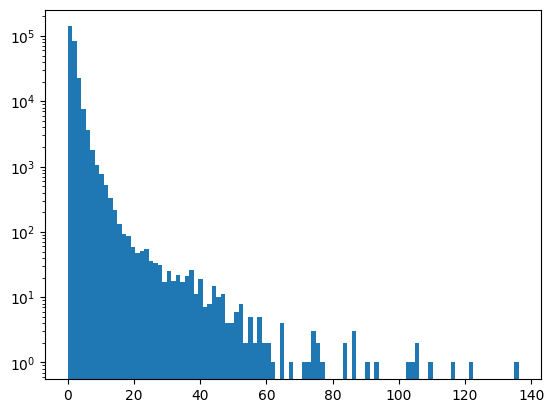

In [8]:
plt.hist(flat_image1, bins=100, log=True);

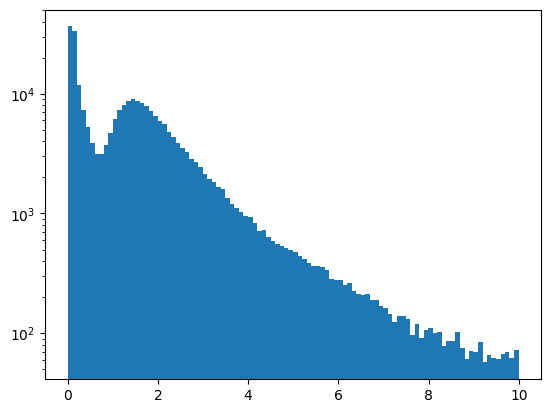

In [9]:
plt.hist(flat_image1[flat_image1<10], bins=100, log=True);

In [10]:

images = aia_data[2010]['131A']
print(type(images))
print(images.shape)

flat_array = images[:].reshape(-1)
print(flat_array.shape)


<class 'zarr.core.Array'>
(471, 512, 512)
(123469824,)


In [11]:
471*512*512

123469824

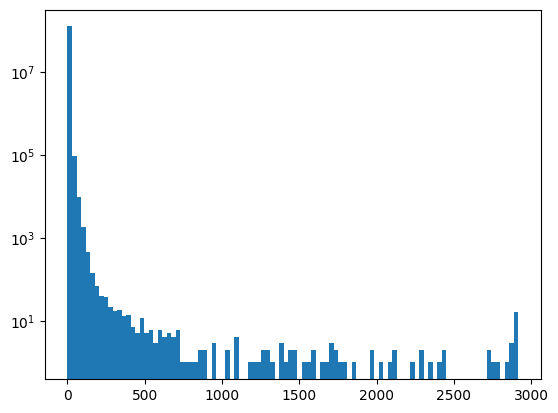

In [12]:
plt.hist(flat_array, bins=100, log=True);

In [15]:
def get_flat_array(zarr_data, years, wavelength):
    """
    Get a flat array of all the pixel values for a given wavelength and a list of years.
    """

    flat_array = np.array([], dtype=np.float16)
    for year in years:
        #a_flat_array = da.from_array(zarr_data[year][wavelength]).reshape(-1)
        a_flat_array = zarr_data[year][wavelength][:].reshape(-1)

        print(type(a_flat_array))
        flat_array = np.concatenate((flat_array, a_flat_array))
    return flat_array

In [16]:
all_pixels_131A = get_flat_array(aia_data, years, '131A')
all_pixels_131A.shape

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


MemoryError: Unable to allocate 80.9 GiB for an array with shape (82822, 512, 512) and data type float32

In [ ]:
type(all_pixels_131A)

dask.array.core.Array

KeyboardInterrupt: 

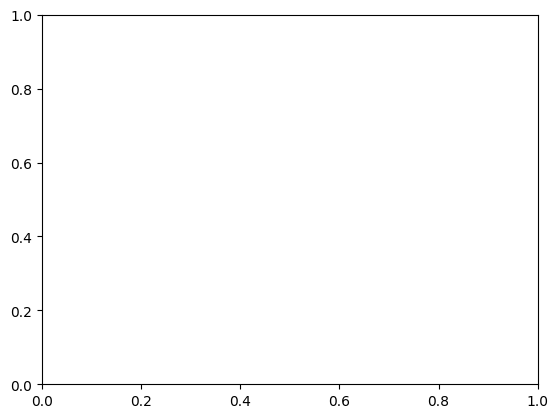

In [ ]:
plt.hist(all_pixels_131A, bins=100, log=True);

In [ ]:
plt.hist(all_pixels_131A[all_pixels_131A<1], bins=100, log=True);

In [ ]:
import pandas as pd

In [ ]:
plt.hist(all_pixels_131A[all_pixels_131A<10], bins=100, log=True)

In [ ]:
plt.hist(all_pixels_131A[all_pixels_131A<100], bins=100, log=True)

In [ ]:
plt.hist(all_pixels_131A[all_pixels_131A<1000], bins=100, log=True)

In [ ]:
plt.hist(all_pixels_131A[all_pixels_131A<10000], bins=100, log=True)